# Requirement Setup

In [1]:
!pip install prophet
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools

In [2]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GRU
import numpy as np
import time
import matplotlib.pyplot as plt

Importing plotly failed. Interactive plots will not work.


# Data Loading

In [3]:
df_nasa = pd.read_csv('datasets/nasa.csv')
df_nasa.columns = ['ds', 'y']
df_nasa['ds'] = pd.to_datetime(df_nasa['ds'])

print(f'NASA DATASET - Dates: {df_nasa["ds"].count()} | Total: {df_nasa["y"].sum()}')
df_nasa.head()

NASA DATASET - Dates: 81396 | Total: 3461612


,ds,y
0,1995-07-01 00:00:00,42
1,1995-07-01 00:01:00,61
2,1995-07-01 00:02:00,57
3,1995-07-01 00:03:00,71
4,1995-07-01 00:04:00,70


In [4]:
df_fifa = pd.read_csv('datasets/fifa.csv')
df_fifa.columns = ['ds', 'y']
df_fifa['ds'] = pd.to_datetime(df_fifa['ds'])

print(f'FIFA DATASET - Dates: {df_fifa["ds"].count()} | Total: {df_fifa["y"].sum()}')
df_fifa.head()

FIFA DATASET - Dates: 125300 | Total: 1352804107


,ds,y
0,1998-04-30 21:30:00,2
1,1998-04-30 21:31:00,11
2,1998-04-30 21:32:00,16
3,1998-04-30 21:33:00,7
4,1998-04-30 21:34:00,3


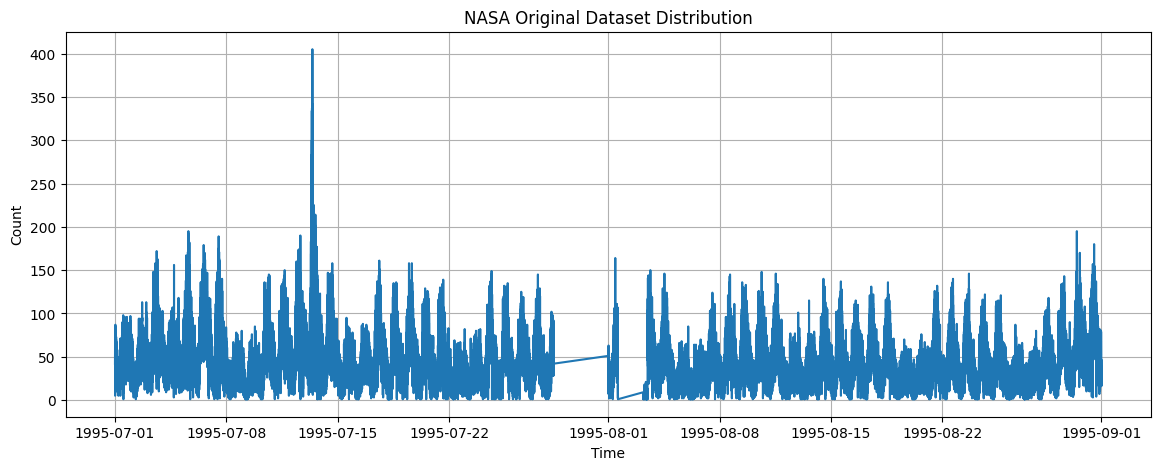

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df_nasa['ds'], df_nasa['y'])
plt.title('NASA Original Dataset Distribution')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid(True)
plt.show()

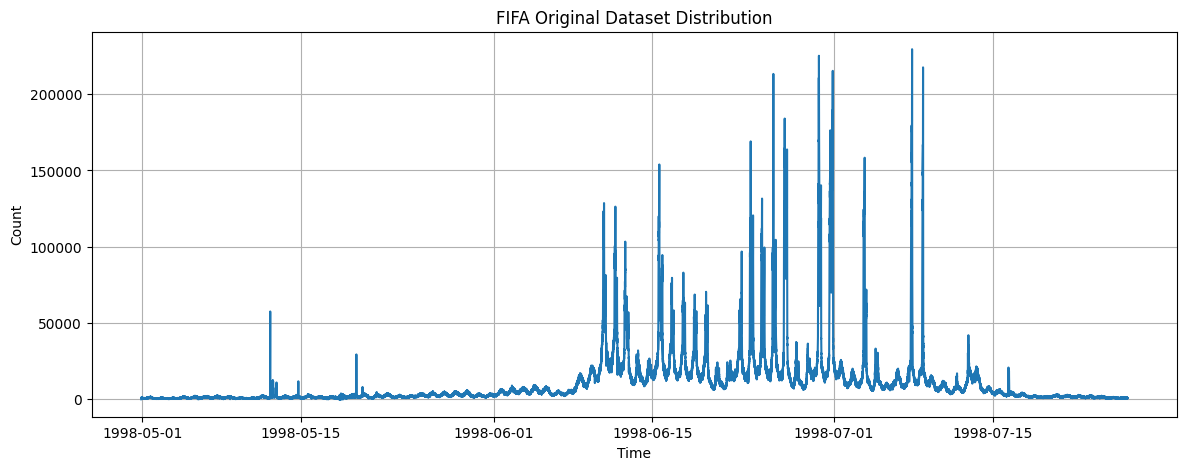

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df_fifa['ds'], df_fifa['y'])
plt.title('FIFA Original Dataset Distribution')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Data Splitting & Preprocessing

1.   Split datasets as 70% training, 30% testing
2.   Fill for empty data
3.   Drop duplicate data





In [7]:
train_df_nasa, test_df_nasa = train_test_split(df_nasa, test_size=0.3, random_state=42, shuffle=False)
train_df_fifa, test_df_fifa = train_test_split(df_fifa, test_size=0.3, random_state=42, shuffle=False)

print(f'NASA DATASET: Train Set: {train_df_nasa.shape} | Test Set: {test_df_nasa.shape}')
print(f'FIFA DATASET: Train Set: {train_df_fifa.shape} | Test Set: {test_df_fifa.shape}')

NASA DATASET: Train Set: (56977, 2) | Test Set: (24419, 2)
FIFA DATASET: Train Set: (87710, 2) | Test Set: (37590, 2)


In [8]:
train_df_nasa['y'].fillna(method='ffill', inplace=True)
train_df_nasa.drop_duplicates(subset='ds', inplace=True)

train_df_fifa['y'].fillna(method='ffill', inplace=True)
train_df_fifa.drop_duplicates(subset='ds', inplace=True)

print(f'NASA DATASET: Train Set: {train_df_nasa.shape} | Test Set: {test_df_nasa.shape}')
print(f'FIFA DATASET: Train Set: {train_df_fifa.shape} | Test Set: {test_df_fifa.shape}')

NASA DATASET: Train Set: (56977, 2) | Test Set: (24419, 2)
FIFA DATASET: Train Set: (87710, 2) | Test Set: (37590, 2)


C:\Users\dilee\AppData\Local\Temp\ipykernel_16296\3859716552.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_nasa['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_16296\3859716552.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_nasa['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_16296\3859716552.py:4: FutureWarning: A value is trying to be

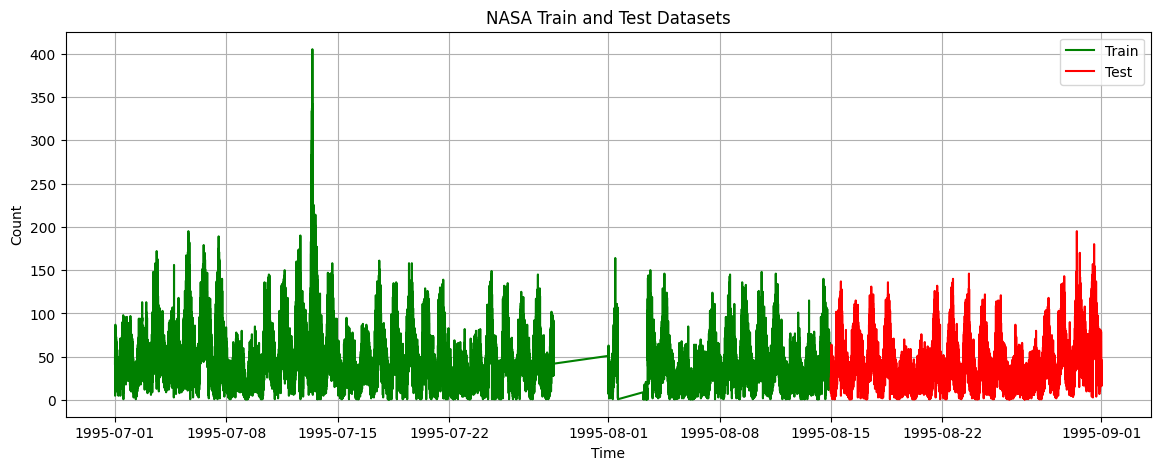

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_nasa['ds'], train_df_nasa['y'], label='Train', color='green')
plt.plot(test_df_nasa['ds'], test_df_nasa['y'], label='Test', color='red')
plt.title('NASA Train and Test Datasets')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.show()

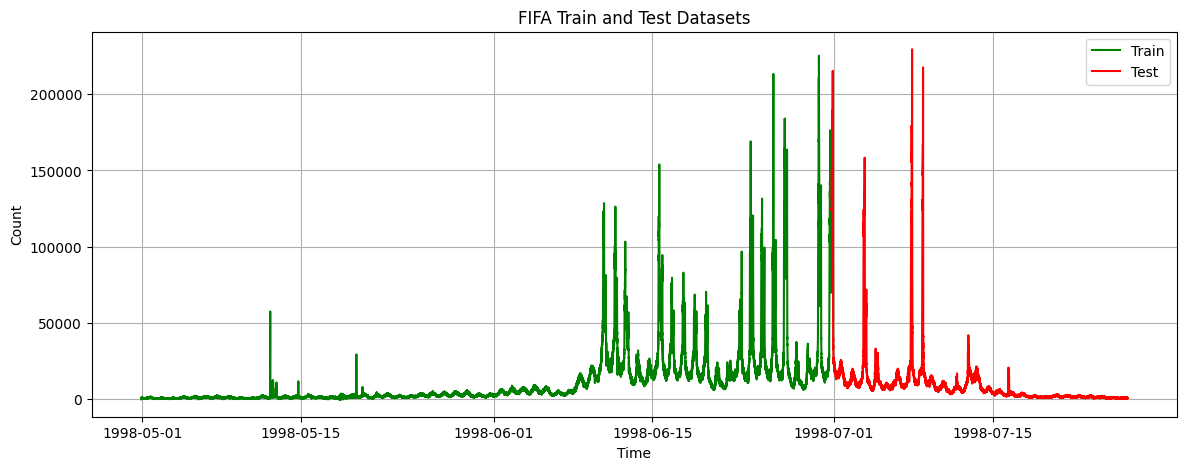

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_fifa['ds'], train_df_fifa['y'], label='Train', color='green')
plt.plot(test_df_fifa['ds'], test_df_fifa['y'], label='Test', color='red')
plt.title('FIFA Train and Test Datasets')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.show()

# Model Training - NASA

## Seasonality Capturing with Prophet

### Train Model

In [11]:
model = Prophet(
    growth='linear',
    changepoint_prior_scale=5.1,
    yearly_seasonality=False,
    weekly_seasonality=20,
    daily_seasonality=50,
    seasonality_prior_scale=30
)
model.fit(train_df_nasa)

10:17:36 - cmdstanpy - INFO - Chain [1] start processing
10:19:25 - cmdstanpy - INFO - Chain [1] done processing


### Predict Dataset

In [12]:
forecast_train_df_nasa = model.predict(train_df_nasa[['ds']].copy())

start_time = time.time()
forecast_test_df_nasa = model.predict(test_df_nasa[['ds']].copy())
end_time = time.time()

In [13]:
forecast_test_df_nasa_analysis = test_df_nasa.copy()
forecast_test_df_nasa_analysis = forecast_test_df_nasa_analysis.merge(forecast_test_df_nasa[['ds', 'yhat']], on='ds', how='left')

mse = mean_squared_error(forecast_test_df_nasa_analysis['y'], forecast_test_df_nasa_analysis['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(forecast_test_df_nasa_analysis['y'], forecast_test_df_nasa_analysis['yhat'])
r2 = r2_score(forecast_test_df_nasa_analysis['y'], forecast_test_df_nasa_analysis['yhat'])

print('=== Facebook Prophet Model Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')
print(f'Prediction Time: {(end_time - start_time) * 1000}ms')

=== Facebook Prophet Model Metrics ===
MSE: 269.05079754569067
RMSE: 16.402767984266884
MAE: 12.573892027687538
R²: 0.5791332022404619
Prediction Time: 5104.389667510986ms


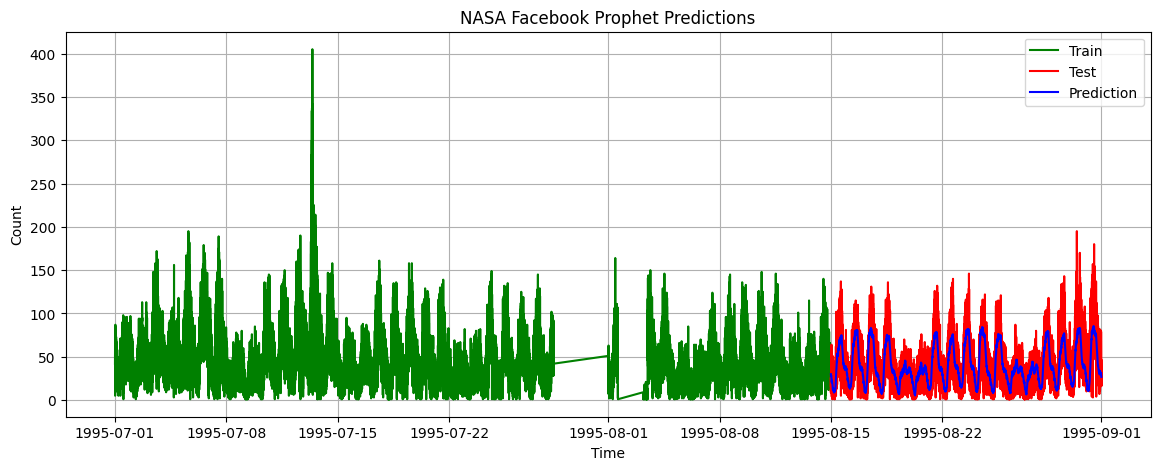

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_nasa['ds'], train_df_nasa['y'], label='Train', color='green')
plt.plot(test_df_nasa['ds'], test_df_nasa['y'], label='Test', color='red')
plt.plot(forecast_test_df_nasa['ds'], forecast_test_df_nasa['yhat'], label='Prediction', color='blue')
plt.title('NASA Facebook Prophet Predictions')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.show()

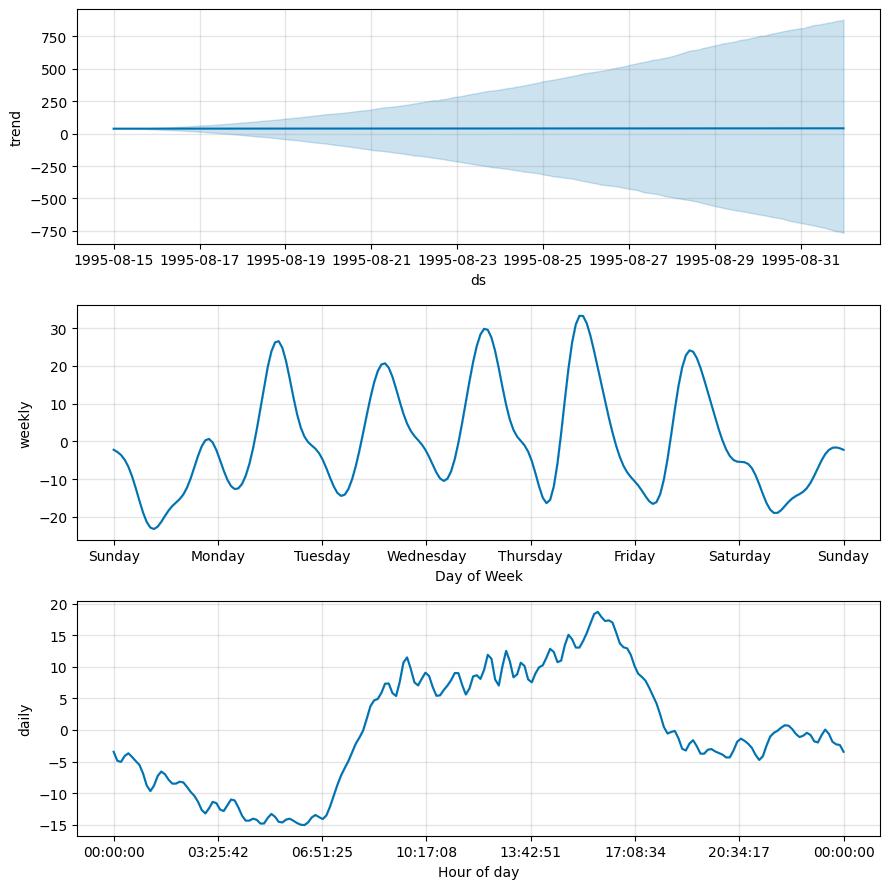

In [15]:
model.plot_components(forecast_test_df_nasa);

## Merge Forecasted Data

In [16]:
forecast_df_nasa = pd.concat([forecast_train_df_nasa, forecast_test_df_nasa])

## Residual Analysis

### Calculate Residuals

In [17]:
df_nasa_residual = df_nasa.merge(forecast_df_nasa[['ds', 'yhat']], on='ds', how='left')
df_nasa_residual['residual'] = df_nasa_residual['y'] - df_nasa_residual['yhat']
df_nasa_residual.head()

,ds,y,yhat,residual
0,1995-07-01 00:00:00,42,48.530058,-6.530058
1,1995-07-01 00:01:00,61,48.308621,12.691379
2,1995-07-01 00:02:00,57,48.083757,8.916243
3,1995-07-01 00:03:00,71,47.861055,23.138945
4,1995-07-01 00:04:00,70,47.646194,22.353806


### Prepare Dataset for LSTM

In [18]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_df_nasa = scaler.fit_transform(df_nasa_residual[['residual']])

In [19]:
def create_dataset(dataset, look_back):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [20]:
look_back = 1
X_nasa, y_nasa = create_dataset(scaled_df_nasa, look_back)

In [21]:
X_train_nasa, X_test_nasa, y_train_nasa, y_test_nasa = train_test_split(X_nasa, y_nasa, test_size=0.3, random_state=42, shuffle=False)

X_train_nasa = np.reshape(X_train_nasa, (X_train_nasa.shape[0], X_train_nasa.shape[1], 1))
X_test_nasa = np.reshape(X_test_nasa, (X_test_nasa.shape[0], X_test_nasa.shape[1], 1))

print(f'NASA DATASET: Train Set: {X_train_nasa.shape} | Test Set: {X_test_nasa.shape}')

NASA DATASET: Train Set: (56976, 1, 1) | Test Set: (24419, 1, 1)


### Train Model

In [22]:
model = Sequential()
model.add(GRU(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(GRU(50, return_sequences=False))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train_nasa, y_train_nasa, epochs=20, batch_size=16, verbose=1)

c:\Users\dilee\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0018
Epoch 2/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0015
Epoch 3/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0015
Epoch 4/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0015
Epoch 5/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0015
Epoch 6/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0015
Epoch 7/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0015
Epoch 8/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0015
Epoch 9/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0015
Epoch 10/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0015
Epoch 11/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.0015
Epoch 12/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 0.0015
Epoch 13/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.0015
Epoch 14/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 0.0015
Epoch 15/20
3561/3561 

### Predict Dataset

In [23]:
nasa_train_predict = model.predict(X_train_nasa)
nasa_train_predict = scaler.inverse_transform(nasa_train_predict)
y_train_nasa_org = scaler.inverse_transform([y_train_nasa])

start_time = time.time()
nasa_test_predict = model.predict(X_test_nasa)
end_time = time.time()
nasa_test_predict = scaler.inverse_transform(nasa_test_predict)
y_test_nasa_org = scaler.inverse_transform([y_test_nasa])

print(f'NASA DATASET - Prediction Size Train: {len(nasa_train_predict)} | Prediction Size Test: {len(nasa_test_predict)}')

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
764/764 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
NASA DATASET - Prediction Size Train: 56976 | Prediction Size Test: 24419


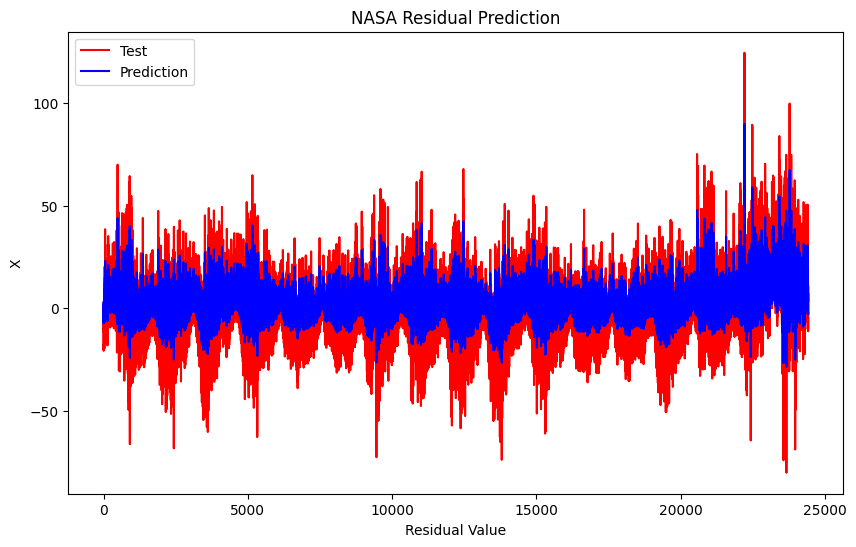

In [24]:
plt.figure(figsize=(10,6))
plt.plot(y_test_nasa_org[0], label='Test', color='red')
plt.plot(nasa_test_predict, label='Prediction', color='blue')
plt.xlabel('Residual Value')
plt.ylabel('X')
plt.title('NASA Residual Prediction')
plt.legend()
plt.show()

In [25]:
mse = mean_squared_error(y_test_nasa_org[0], nasa_test_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_nasa_org[0], nasa_test_predict)
r2 = r2_score(y_test_nasa_org[0], nasa_test_predict)

print('=== LSTM Residual Analysis Model Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')
print(f'Prediction Time: {(end_time - start_time) * 1000}ms')

=== LSTM Residual Analysis Model Metrics ===
MSE: 214.30710978027042
RMSE: 14.639231871251662
MAE: 11.300657865055433
R2: 0.1928286285377281
Prediction Time: 1613.9161586761475ms


## Combine Results from Both Models

In [26]:
nasa_combine_predict = np.concatenate((nasa_train_predict, nasa_test_predict))

final_df_nasa = df_nasa_residual.copy()

final_df_nasa['residual_predict'] = np.nan
final_df_nasa['residual_predict'].iloc[0:len(nasa_combine_predict)] = nasa_combine_predict[:, 0]
print(f'NASA DATASET: Total Output: {final_df_nasa.shape[0]} | Loss: {final_df_nasa['residual_predict'].isna().sum()}')

final_df_nasa['residual_predict'] = final_df_nasa['residual_predict'].fillna(final_df_nasa['residual'])

final_df_nasa['y_predicted'] = final_df_nasa['yhat'] + final_df_nasa['residual_predict']

final_df_nasa.head()

NASA DATASET: Total Output: 81396 | Loss: 1


C:\Users\dilee\AppData\Local\Temp\ipykernel_16296\867113017.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  final_df_nasa['residual_predict'].iloc[0:len(nasa_combine_predict)] = nasa_combine_predict[:, 0]
C:\Users\dilee\AppData\Local\Tem

,ds,y,yhat,residual,residual_predict,y_predicted
0,1995-07-01 00:00:00,42,48.530058,-6.530058,-0.967246,47.562813
1,1995-07-01 00:01:00,61,48.308621,12.691379,8.502217,56.810839
2,1995-07-01 00:02:00,57,48.083757,8.916243,6.554912,54.638669
3,1995-07-01 00:03:00,71,47.861055,23.138945,14.126194,61.987249
4,1995-07-01 00:04:00,70,47.646194,22.353806,13.691277,61.337470


### Extract Test Dataset Related Dataframe & Calculate Metrics

In [27]:
final_df_nasa_analysis = final_df_nasa.iloc[train_df_nasa.shape[0]:]
final_df_nasa_analysis.tail()

print(f'NASA DATASET: Testing Output: {final_df_nasa_analysis.shape}')

NASA DATASET: Testing Output: (24419, 6)


In [28]:
mse = mean_squared_error(final_df_nasa_analysis['y'], final_df_nasa_analysis['y_predicted'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(final_df_nasa_analysis['y'], final_df_nasa_analysis['y_predicted'])
r2 = r2_score(final_df_nasa_analysis['y'], final_df_nasa_analysis['y_predicted'])

print('=== Hybrid Model Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')

=== Hybrid Model Metrics ===
MSE: 81.62968493156335
RMSE: 9.034914771682317
MAE: 7.070254479678765
R²: 0.8723095251429879


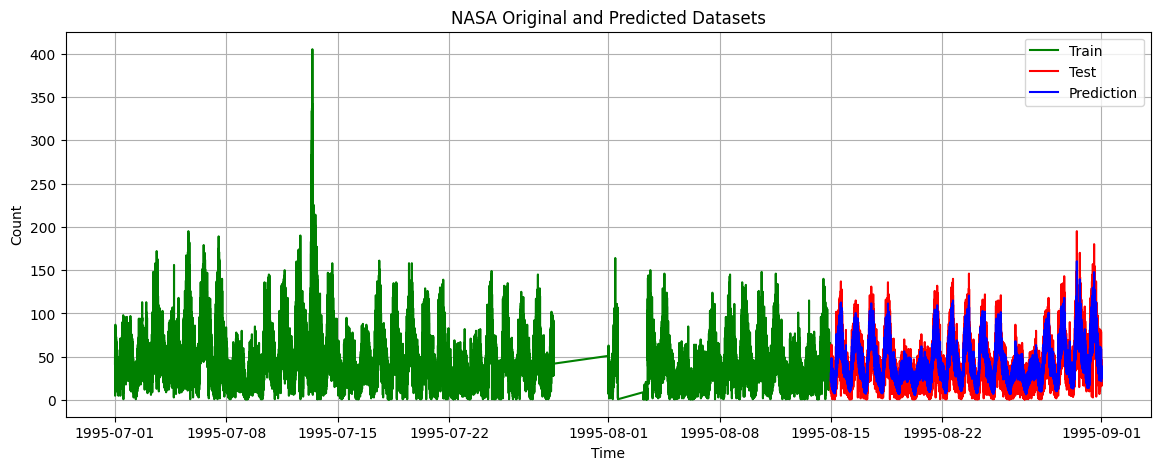

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_nasa['ds'], train_df_nasa['y'], label='Train', color='green')
plt.plot(test_df_nasa['ds'], test_df_nasa['y'], label='Test', color='red')
plt.plot(final_df_nasa_analysis['ds'], final_df_nasa_analysis['y_predicted'], label='Prediction', color='blue')
plt.title('NASA Original and Predicted Datasets')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.show()